In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
df_train = pd.read_csv("C:/Users/steve/CSV Datasets/loan_prediction/train.csv")
df_test = pd.read_csv("C:/Users/steve/CSV Datasets/loan_prediction/test.csv")
#df_train.drop('id', axis=1, index=True)
#df_test.drop('id', axis=1, inplace=True)

In [3]:
df_train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
df_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [5]:
df_train.drop(columns=['id'], axis=1, inplace=True)
df_test.drop(columns=['id'], axis=1, inplace=True)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         254569 non-null  float64
 1   debt_to_income_ratio  254569 non-null  float64
 2   credit_score          254569 non-null  int64  
 3   loan_amount           254569 non-null  float64
 4   interest_rate         254569 non-null  float64
 5   gender                254569 non-null  object 
 6   marital_status        254569 non-null  object 
 7   education_level       254569 non-null  object 
 8   employment_status     254569 non-null  object 
 9   loan_purpose          254569 non-null  object 
 10  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.4+ MB


In [8]:
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder

In [9]:
rand_seed = 111
target = 'loan_paid_back'

cat_cols = df_train.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df_train.select_dtypes(include='number').columns if c != target]

print(f"\n🔵 Initial categorical columns: {cat_cols}")
print(f"🔵 Initial numeric columns: {num_cols}")
print(f"🔵 Train shape: {df_train.shape} | Test shape: {df_test.shape}")


🔵 Initial categorical columns: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
🔵 Initial numeric columns: ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
🔵 Train shape: (593994, 12) | Test shape: (254569, 11)


In [10]:
# --- Step 1: Consistent dtype for categoricals ---
def convert_dtype(df, cat_cols):
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].astype('category')
    return df

print("\n🔄 Converting dtypes for categoricals...\n")
df_train_fe = convert_dtype(df_train, cat_cols)
df_test_fe = convert_dtype(df_test, cat_cols)
print("Finished converting....")


🔄 Converting dtypes for categoricals...

Finished converting....


In [11]:
# --- Step 2: Label Encoding ---
def encode_categorical(tr_df, ts_df, cols):
    tr_df, ts_df = tr_df.copy(), ts_df.copy()
    for col in cols:
        le = LabelEncoder()
        tr_df[col] = le.fit_transform(tr_df[col].astype(str))
        mapped = ts_df[col].astype(str).map(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        ts_df[col] = le.transform(mapped)
        print(f"   ✓ Label encoded {col} | Classes: {len(le.classes_)}")

    return tr_df, ts_df

print("\n🔄 Label encoding categoricals...\n")
df_train_fe, df_test_fe = encode_categorical(df_train_fe, df_test_fe, cat_cols)


🔄 Label encoding categoricals...

   ✓ Label encoded gender | Classes: 3
   ✓ Label encoded marital_status | Classes: 4
   ✓ Label encoded education_level | Classes: 5
   ✓ Label encoded employment_status | Classes: 5
   ✓ Label encoded loan_purpose | Classes: 8
   ✓ Label encoded grade_subgrade | Classes: 30


In [12]:
# --- Step 3: Numeric Interactions ---
def num_inter(df, num_cols):
    df = df.copy()
    pairs = [(i, j) for i in range(len(num_cols)) for j in range(i+1, len(num_cols))]
    for i, j in pairs:
        c1, c2 = num_cols[i], num_cols[j]
        df[f'{c1}_plus_{c2}'] = df[c1] + df[c2]
        df[f'{c1}_times_{c2}'] = df[c1] * df[c2]
        df[f'{c1}_div_{c2}'] = df[c1] / (df[c2].replace(0, 1e-5) + 1e-5)
    print(f"   ✓ Added {len(pairs)*3} numeric interaction features.")
    return df

print("\n🔄 Adding numeric interactions...")
df_train_fe = num_inter(df_train_fe, num_cols)
df_test_fe  = num_inter(df_test_fe, num_cols)


🔄 Adding numeric interactions...
   ✓ Added 30 numeric interaction features.
   ✓ Added 30 numeric interaction features.


In [13]:
# --- Step 4: Numeric Transformations & Binning ---
def num_trans(df, num_cols, ref_df=None):
    df = df.copy()
    binned, logged, rooted = 0, 0, 0
    for col in num_cols:
        if ref_df is not None:
            try:
                _, bin_edges = pd.qcut(ref_df[col], 5, retbins=True, duplicates='drop')
                df[f'{col}_bin'] = pd.cut(df[col], bins=bin_edges, labels=False, include_lowest=True)
                binned += 1

            except Exception:
                continue
        else:
            try:
                df[f'{col}_bin'] = pd.qcut(df[col], 5, labels=False, duplicates='drop')
                binned += 1

            except Exception:
                continue

        df[f'{col}_log'] = np.log1p(np.abs(df[col])); logged += 1
        df[f'{col}_sqrt'] = np.sqrt(np.abs(df[col])); rooted += 1
    print(f"   ✓ Binned: {binned}, Log-transformed: {logged}, Sqrt: {rooted}")
    return df

print("\n🔄 Numeric transforms and binning...")
df_train_fe = num_trans(df_train_fe, num_cols, ref_df=df_train_fe)
df_test_fe  = num_trans(df_test_fe, num_cols, ref_df=df_train_fe)


🔄 Numeric transforms and binning...
   ✓ Binned: 5, Log-transformed: 5, Sqrt: 5
   ✓ Binned: 5, Log-transformed: 5, Sqrt: 5


In [14]:
# --- Step 5: Grade/Sub-Grade split ---
print("\n🔄 Splitting grade_subgrade into grade and sub_grade...")
df_train_fe['grade'] = df_train_fe['grade_subgrade'].astype(str).str[0]
df_train_fe['sub_grade'] = df_train_fe['grade_subgrade'].astype(str).str[1]

df_test_fe['grade'] = df_train_fe['grade_subgrade'].astype(str).str[0]
df_test_fe['sub_grade'] = df_train_fe['grade_subgrade'].astype(str).str[1]
print(f"\n   ✓ Added 'grade' and 'sub_grade' columns.")


🔄 Splitting grade_subgrade into grade and sub_grade...

   ✓ Added 'grade' and 'sub_grade' columns.


In [15]:
# --- Step 6: Scaling numerics ---
exclude_for_scaling = set(cat_cols + [target])
scale_cols = [
    c for c in df_train_fe.columns 
    if c not in exclude_for_scaling 
    and df_train_fe[c].dtype in [np.float64, np.int64, float, int]
]

print(f"\n🔄 Scaling {len(scale_cols)} numeric columns...\n")
scaler = StandardScaler()
df_train_fe[scale_cols] = scaler.fit_transform(df_train_fe[scale_cols])
df_test_fe[scale_cols]  = scaler.transform(df_test_fe[scale_cols])

print("   ✓ Finished scaling.")


🔄 Scaling 50 numeric columns...

   ✓ Finished scaling.


In [16]:
from category_encoders import TargetEncoder

# --- Step 7: Target encoding ---
bin_features = ['annual_income', 'loan_amount', 'credit_score']
te_cols = [col+'_bin' for col in bin_features] + ['grade', 'sub_grade']
print(f"\n🔄 Target encoding columns: {te_cols}\n")
te = TargetEncoder(cols=te_cols)

te.fit(df_train_fe.drop(columns=[target]), df_train_fe[target])
df_train_fe = te.transform(df_train_fe.drop(columns=[target]))
df_test_fe  = te.transform(df_test_fe)
print("   ✓ Target encoding complete.")


🔄 Target encoding columns: ['annual_income_bin', 'loan_amount_bin', 'credit_score_bin', 'grade', 'sub_grade']

   ✓ Target encoding complete.


In [17]:
x = df_train_fe
y = df_train[target]
x_test = df_test_fe

print(f"\n✅ Feature engineering complete. \nX shape: {x.shape}, \nX_test shape: {x_test.shape}\n")


✅ Feature engineering complete. 
X shape: (593994, 58), 
X_test shape: (254569, 58)



In [18]:
#  !pip install lightgbm

In [19]:
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier
import warnings
warnings.filterwarnings('ignore')

In [20]:
def blended_feature_selection(
    df_train, df_test, target_col='loan_paid_back', n_features=50, mi_thresh=.03, lgb_thresh=.03, et_thresh=.03,
    min_sources=2
):
    print("\n=*= FEATURE SELECTION PIPELINE (Multiple Importances, Robust) =*=\n")
    y = df_train[target_col]
    x_train = df_train.drop(columns=[target_col])
    x_test = df_test.copy()

    # Remove constant features
    constant_features = [
        c for c in x_train.columns 
        if x_train[c].nunique(dropna=False) <= 1
    ]
    if constant_features:
        print(f"✓ Dropped {len(constant_features)} constant features: {constant_features}\n")
    x_train = x_train.drop(columns=constant_features)
    x_test = x_test.drop(columns=constant_features, errors='ignore')

    # Remove highly correlated features
    corr_matrix = x_train.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [
        col for col in upper_tri.columns
        if (upper_tri[col] > .99).any()
    ]
    if high_corr:
        print(f"✓ Dropped {len(high_corr)} highly correlated features: {high_corr}\n")
    x_train = x_train.drop(columns=high_corr)
    x_test = x_test.drop(columns=high_corr, errors='ignore')

    num_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
    xf = x_train[num_cols].fillna(0)    # For selectors

    print("🔎 Calculating importances and selecting features...\n")
    # Mutual Info
    mi_scores = mutual_info_classif(xf, y, random_state=42)
    mi_scores_norm = mi_scores / (np.max(mi_scores) + 1e-10)
    mi_features = [f for f, s in zip(num_cols, mi_scores_norm) if s > mi_thresh]

    # LightGBM
    lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, importance_type='gain')
    lgb_model.fit(xf, y)
    lgb_imp = lgb_model.feature_importances_
    lgb_imp_norm = lgb_imp / (np.max(lgb_imp) + 1e-10)
    lgb_features = [f for f, s in zip(num_cols, lgb_imp_norm) if s > lgb_thresh]

    # Extra Trees
    et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
    et_model.fit(xf, y)
    et_imp = et_model.feature_importances_
    et_imp_norm = et_imp / (np.max(et_imp) + 1e-10)
    et_features = [f for f, s in zip(num_cols, et_imp_norm) if s > et_thresh]

    # Create robust selector: keep only features identified by at least two selectors
    selectors = {'mi': mi_features, 'lgb': lgb_features, 'et': et_features}
    def count_sources(feat):
        return sum([feat in selectors[s] for s in selectors])

    print("  Counting agreement of sources for each feature...")
    agreement = {f: count_sources(f) for f in num_cols}
    robust_features = [f for f, cnt in agreement.items() if cnt >= min_sources]
    print(f"★ Features with agreement from at least {min_sources} selectors: {len(robust_features)}\n")

    # Average rank filter (only rank robust features)
    imp_df = pd.DataFrame({
        'feature': num_cols,
        'mi': mi_scores_norm,
        'lgb': lgb_imp_norm,
        'et': et_imp_norm
    })
    for c in ['mi', 'lgb', 'et']:
        imp_df[f'{c}_rank'] = imp_df[c].rank(ascending=False)
    imp_df['avg_rank'] = imp_df[[f'{c}_rank' for c in ['mi', 'lgb', 'et']]].mean(axis=1)

    imp_df = imp_df[imp_df['feature'].isin(robust_features)]
    imp_df = imp_df.sort_values('avg_rank')
    selected = imp_df['feature'].tolist()[:n_features]

    print(f"✅ Robust selected features ({len(selected)}):\n - {selected[:10]}{' ...' if len(selected) > 10 else ''}\n")
    x_final = x_train[selected].copy()
    x_test_final = x_test[selected].copy()
    print(f"✏️ X_final: {x_final.shape}, X_test_final: {x_test_final.shape}")

    return x_final, x_test_final, y


In [21]:
# Usage
df_train_blend = x.copy()
df_train_blend[target] = y

In [22]:
x_final, x_test_final, _ = blended_feature_selection(
    df_train_blend, x_test, target_col='loan_paid_back',
    n_features=50, mi_thresh=.03, lgb_thresh=.03, et_thresh=.03,
    min_sources=2
)


=*= FEATURE SELECTION PIPELINE (Multiple Importances, Robust) =*=

✓ Dropped 15 highly correlated features: ['annual_income_plus_debt_to_income_ratio', 'annual_income_plus_credit_score', 'annual_income_plus_interest_rate', 'debt_to_income_ratio_plus_credit_score', 'debt_to_income_ratio_plus_loan_amount', 'debt_to_income_ratio_plus_interest_rate', 'credit_score_plus_loan_amount', 'credit_score_plus_interest_rate', 'loan_amount_plus_interest_rate', 'debt_to_income_ratio_log', 'debt_to_income_ratio_sqrt', 'credit_score_log', 'credit_score_sqrt', 'interest_rate_log', 'interest_rate_sqrt']

🔎 Calculating importances and selecting features...

[LightGBM] [Info] Number of positive: 474494, number of negative: 119500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7757
[LightGBM] [Info] Number of data points in the train set: 593994, number of used fea

In [23]:
#%pip uninstall xgboost

In [24]:
#%pip install xgboost --upgrade

In [25]:
import gc, sys, os, warnings
from copy import deepcopy
from contextlib import contextmanager

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool


In [26]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)


In [27]:
@contextmanager
def suppress_output():
    devnull = open(os.devnull, 'w')
    old_out, old_err = sys.stdout, sys.stderr
    try:
        sys.stdout, sys.stderr = devnull, devnull
        yield

    finally:
        sys.stdout, sys.stderr = old_out, old_err
        devnull.close()


In [28]:

def detect_cats(df: pd.DataFrame):
    return list(df.select_dtypes(include=['object', 'category']).columns)


In [29]:
def align_categories(x: pd.DataFrame, x_test: pd.DataFrame, cat_cols):
    xc, xt = x.copy(), x_test.copy()
    for c in cat_cols:
        base = pd.Index(xc[c].astype('category').cat.categories)
        if c in xt.columns:
            base = base.union(pd.Index(xt[c].astype('category').cat.categories))

        xc[c] = xc[c].astype('category').cat.set_categories(base)
        if c in xt.columns:
            xt[c] = xt[c].astype('category').cat.set_categories(base)

    return xc, xt

In [30]:
def fix_dtypes_for_lgb(df: pd.DataFrame, cat_cols):
    df = df.copy()
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype('category')

    for c in df.columns:
        if df[c].dtype == 'object':
            df[c] = df[c].astype('category')

    return df

In [31]:
# -----------------------------
# Your BEST parameters (as provided)
# -----------------------------

BEST_LGBM = {
    'learning_rate': 0.06189585591734019,
    'num_leaves': 71,
    'max_depth': 3,
    'min_child_samples': 47,
    'subsample': 0.7882534840295796,
    'colsample_bytree': 0.50516850988847,
    'reg_alpha': 4.108406108850896,
    'reg_lambda': 0.7082653396924283,
    'n_estimators': 4040,
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
    'verbosity': -1
}

BEST_XGB = {
    'learning_rate': 0.06688084442321802,
    'max_depth': 3,
    'min_child_weight': 57,
    'subsample': 0.853551584789076,
    'colsample_bytree': 0.9782757144921325,
    'colsample_bylevel': 0.5465267973481097,
    'gamma': 0.942315585496616,
    'reg_alpha': 4.943158155300519,
    'reg_lambda': 1.4827433844229039,
    'n_estimators': 3261,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'enable_categorical': True,
    'scale_pos_weight': 0.25184723094496453,  # as provided
    'n_jobs': -1,
    'verbosity': 0,
    'random_state': 42
}

BEST_CAT = {
    'iterations': 658,
    'depth': 4,
    'learning_rate': 0.14892724411121927,
    'subsample': 0.6720305549704694,
    'colsample_bylevel': 0.6201948153318813,
    'l2_leaf_reg': 4.593721851846689,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': False
}

In [32]:
# -----------------------------
# Single-seed L0 fit
# -----------------------------
#from xgboost.callback import EarlyStopping

def fit_l0_one_seed(
    x, y, x_test, models=('lgbm','xgb','cat'), n_folds: int = 7, seed: int = 123, es_rounds: int = 200
):
    cat_cols = detect_cats(x)
    x_aligned, xtest_aligned = align_categories(x, x_test, cat_cols)

    x_lgb = fix_dtypes_for_lgb(x_aligned, cat_cols)
    xtest_lgb = fix_dtypes_for_lgb(xtest_aligned, cat_cols)

    cat_idx = [x_aligned.columns.get_loc(c) for c in cat_cols if c in x_aligned.columns]

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    oof_preds = {m: np.zeros(len(x), dtype=float) for m in models}
    test_preds = {m: np.zeros(len(x_test), dtype=float) for m in models}

    print("="*62)
    print(f"L0 training (seed={seed}) | models={list(models)} | folds={n_folds}")
    print("="*62)

    for m in models:
        print(f"\n🚀 Fitting {m.upper()} ...")
        fold_test = np.zeros((n_folds, len(x_test)), dtype=float)

        for i, (tr, va) in enumerate(skf.split(x_aligned, y), 1):
            y_tr, y_va = y.iloc[tr], y.iloc[va]

            with suppress_output():
                if m == 'lgbm':
                    model = LGBMClassifier(**deepcopy(BEST_LGBM), n_jobs=-1)
                    model.fit(
                        x_lgb.iloc[tr], y_tr,
                        eval_set=[(x_lgb.iloc[va], y_va)],
                        categorical_feature=[c for c in x_lgb.columns if x_lgb[c].dtype.name == 'category'],
                        callbacks=[lgb.early_stopping(es_rounds), lgb.log_evaluation(0)]
                    )
                    va_pred = model.predict_proba(x_lgb.iloc[va])[:, 1]
                    te_pred = model.predict_proba(xtest_lgb)[:, 1]

                elif m == 'xgb':
                    params = deepcopy(BEST_XGB)
                    params['random_state'] = seed
                    model = XGBClassifier(**params, early_stopping_rounds=es_rounds)
                    model.fit(
                        x_aligned.iloc[tr], y_tr,
                        eval_set=[(x_aligned.iloc[va], y_va)],
                        #eval_metric="logloss",
                        #early_stopping_rounds=es_rounds,
                        #callbacks=[EarlyStopping(rounds=es_rounds, metric_name="logloss")],
                        verbose=False
                    )
                    va_pred = model.predict_proba(x_aligned.iloc[va])[:, 1]
                    te_pred = model.predict_proba(xtest_aligned)[:, 1]

                else:
                    params = deepcopy(BEST_CAT)
                    params['random_seed'] = seed
                    train_pool = Pool(x_aligned.iloc[tr], y_tr, cat_features=cat_idx)
                    val_pool = Pool(x_aligned.iloc[va], y_va, cat_features=cat_idx)
                    test_pool = Pool(xtest_aligned, cat_features=cat_idx)
                    model = CatBoostClassifier(**params, early_stopping_rounds=es_rounds)
                    model.fit(
                        train_pool,
                        eval_set=val_pool,
                        use_best_model=True,
                        #early_stopping_rounds=es_rounds,
                        verbose=False
                    )
                    va_pred = model.predict_proba(val_pool)[:, 1]
                    te_pred = model.predict_proba(test_pool)[:, 1]

            oof_preds[m][va] = va_pred
            fold_test[i-1] = te_pred
            print(f"   [{m.upper()}|seed={seed}] Fold {i}/{n_folds} AUC: {roc_auc_score(y_va, va_pred):.5f}")

            del model; gc.collect()

        test_preds[m] = fold_test.mean(axis=0)
        print(f"[{m.upper()}] OOF AUC (seed={seed}): {roc_auc_score(y, oof_preds[m]):.5f}")

    x_meta_train = pd.DataFrame({m: oof_preds[m] for m in models})
    x_meta_test = pd.DataFrame({m: test_preds[m] for m in models})
    return oof_preds, test_preds, x_meta_train, x_meta_test

In [33]:
def fit_10_multi_seed(
        x, y, x_test,
    models=('lgbm', 'xgb', 'cat'),
    n_folds: int = 7,
    seeds=(42, 77, 123),
    es_rounds: int = 200
):
    oof_acc  = {m: np.zeros(len(x), dtype=float)     for m in models}
    test_acc = {m: np.zeros(len(x_test), dtype=float) for m in models}

    for sd in seeds:
        oof_s, test_s, _, _ = fit_l0_one_seed(
            x, y, x_test,
            models=models, n_folds=n_folds, seed=sd, es_rounds=es_rounds
        )
        for m in models:
            oof_acc[m] += oof_s[m]
            test_acc[m] += test_s[m]

    for m in models:
        oof_acc[m] /= float(len(seeds))
        test_acc[m] /= float(len(seeds))

    x_meta_train = pd.DataFrame({m: oof_acc[m] for m in models})
    x_meta_test = pd.DataFrame({m: test_acc[m] for m in models})

    print("\n" + "="*62)
    print("Averaged across seeds:")
    for m in models:
        print(f'  {m.upper()} OOF AUC (avg): {roc_auc_score(y, oof_acc[m]):.5f}')
    print('='*62)

    return oof_acc, test_acc, x_meta_train, x_meta_test


if __name__ == '__main__':

    oof_preds, test_preds, x_meta_train, x_meta_test = fit_10_multi_seed(
        x, y, x_test,
        models=('lgbm', 'xgb', 'cat'),
        n_folds=7,
        seeds=(42, 77, 123),
        es_rounds=200
    )

    lgb_oof, xgb_oof, cat_oof = oof_preds['lgbm'], oof_preds['xgb'], oof_preds['cat']
    lgb_test, xgb_test, cat_test = test_preds['lgbm'], test_preds['xgb'], test_preds['cat']

    print("\n✅ L0 multi-seed finished.")
    print("Meta-train shape:", x_meta_train.shape, "| Meta-test shape:", x_meta_test.shape)
    

L0 training (seed=42) | models=['lgbm', 'xgb', 'cat'] | folds=7

🚀 Fitting LGBM ...
   [LGBM|seed=42] Fold 1/7 AUC: 0.92405
   [LGBM|seed=42] Fold 2/7 AUC: 0.92365
   [LGBM|seed=42] Fold 3/7 AUC: 0.92307
   [LGBM|seed=42] Fold 4/7 AUC: 0.92158
   [LGBM|seed=42] Fold 5/7 AUC: 0.92125
   [LGBM|seed=42] Fold 6/7 AUC: 0.92315
   [LGBM|seed=42] Fold 7/7 AUC: 0.92210
[LGBM] OOF AUC (seed=42): 0.92269

🚀 Fitting XGB ...
   [XGB|seed=42] Fold 1/7 AUC: 0.92320
   [XGB|seed=42] Fold 2/7 AUC: 0.92191
   [XGB|seed=42] Fold 3/7 AUC: 0.92156
   [XGB|seed=42] Fold 4/7 AUC: 0.92052
   [XGB|seed=42] Fold 5/7 AUC: 0.91982
   [XGB|seed=42] Fold 6/7 AUC: 0.92125
   [XGB|seed=42] Fold 7/7 AUC: 0.92097
[XGB] OOF AUC (seed=42): 0.92132

🚀 Fitting CAT ...
   [CAT|seed=42] Fold 1/7 AUC: 0.92294
   [CAT|seed=42] Fold 2/7 AUC: 0.92213
   [CAT|seed=42] Fold 3/7 AUC: 0.92189
   [CAT|seed=42] Fold 4/7 AUC: 0.92060
   [CAT|seed=42] Fold 5/7 AUC: 0.92015
   [CAT|seed=42] Fold 6/7 AUC: 0.92176
   [CAT|seed=42] Fold 7/

In [76]:
from scipy.stats import rankdata
import sklearn
from scipy.optimize import minimize

In [80]:
lgb_score = roc_auc_score(y, lgb_oof)
xgb_score = roc_auc_score(y, xgb_oof)
cat_score = roc_auc_score(y, cat_oof)
print(f"[L0] OOF AUCs -> LGBM: {lgb_score:.5f} | XGB: {xgb_score:.5f} | CAT: {cat_score:.5f}")

total = lgb_score + xgb_score + cat_score
w_lgb = lgb_score / total
w_xgb = xgb_score / total
w_cat = cat_score / total
weighted_test = w_lgb * lgb_test + w_xgb * xgb_test + w_cat * cat_test
weighted_oof = w_lgb * lgb_oof + w_xgb * xgb_oof + w_cat * cat_oof

sum_sq = lgb_score**2 + xgb_score**2 + cat_score**2
w_lgb2 = lgb_score**2 / total
w_xgb2 = xgb_score**2 / total
w_cat2 = cat_score**2 / total
opt_test = w_lgb2 * lgb_test + w_xgb2 * xgb_test + w_cat2 * cat_test
opt_oof = w_lgb2 * lgb_oof + w_xgb2 * xgb_oof + w_cat2 * cat_oof

def rank01(a):
    r = rankdata(a) - 1
    return r / (len(a) - 1)
rank_test = (rank01(lgb_test) + rank01(xgb_test) + rank01(cat_test)) / 3.0
rank_oof = (rank01(lgb_oof) + rank01(xgb_oof) + rank01(cat_oof)) / 3.0

ensemble_test = 0.4 * weighted_test + 0.3 * rank_test + 0.3 * opt_test
ensemble_oof = 0.4 * weighted_oof + 0.3 * rank_oof + 0.3 * opt_oof

oofs = np.vstack([lgb_oof, xgb_oof, cat_oof]).T
tests = np.vstack([lgb_test, xgb_test, cat_test]).T

def neg_auc(w):
    w = np.clip(w, 0, 1)
    s = w.sum()
    if s == 0:
        w = np.array([1/3, 1/3, 1/3])

    else:
        w = w /s

    blend = oofs @ w
    return - roc_auc_score(y, blend)

cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1})
bounds = [(0, 1)]*3
w0 = np.array([1/3, 1/3, 1/3])
res = minimize(neg_auc, w0, method='SLSQP', bounds=bounds, constraints=cons)
w_opt = res.x / res.x.sum()
opt_oof_auc = roc_auc_score(y, (oofs @ w_opt))
print(f"[L0 Blend Opt] Weights LGB/XGB/CAT = {w_opt[0]:.3f}, {w_opt[1]:.3f}, {w_opt[2]:.3f} | OOF AUC: {opt_oof_auc:.5f}")

optimized_l0_test = tests @ w_opt
optimized_l0_oof = oofs @ w_opt

x_meta_train = pd.DataFrame(
    {
        'lgbm': lgb_oof,
        'xgb': xgb_oof,
        'cat': cat_oof
    }
)

x_meta_test = pd.DataFrame(
    {
        'lgbm': lgb_test,
        'xgb': xgb_test,
        'cat': cat_test
    }
)

n_folds = 7
meta_skf = sklearn.model_selection.StratifiedKFold(
    n_splits=n_folds, shuffle=True, random_state=42
)

logreg_oof = np.zeros(len(x_meta_train))
logreg_test_f = np.zeros((n_folds, len(x_meta_test)))

for f, (tr_idx, va_idx) in enumerate(meta_skf.split(x_meta_train, y), 1):
    xm_tr, xm_va = x_meta_train.iloc[tr_idx], x_meta_train.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    logreg = sklearn.linear_model.LogisticRegression(
        C=1.0, penalty='l2', solver='lbfgs', max_iter=2000, class_weight='balanced', random_state=42
    )
    logreg.fit(xm_tr, y_tr)
    logreg_oof[va_idx] = logreg.predict_proba(xm_va)[:, 1]
    logreg_test_f[f-1] = logreg.predict_proba(x_meta_test)[:, 1]

logreg_pred = logreg_test_f.mean(axis=0)
print(f"[Stacker LR] OOF ROC AUC: {roc_auc_score(y, logreg_oof):.5f}")

final_prediction = 0.5 * logreg_pred + 0.5 * optimized_l0_test

submission = pd.read_csv("C:/Users/steve/CSV Datasets/loan_prediction/sample_submission.csv")
submission['loan_paid_back'] = final_prediction
submission.to_csv('Submission with_all_blended_models', index=False)

print("✅ Saved: Submission with_all_blended_models.csv")

[L0] OOF AUCs -> LGBM: 0.92308 | XGB: 0.92153 | CAT: 0.92175
[L0 Blend Opt] Weights LGB/XGB/CAT = 0.546, 0.000, 0.454 | OOF AUC: 0.92312
[Stacker LR] OOF ROC AUC: 0.92323
✅ Saved: Submission with_all_blended_models.csv


In [96]:
columns = [9, 8, 7, 6, 5, 4, 3, 0]
data = pd.DataFrame({
    'name': ['Steve', 'Bicko', 'Sam', 'Charles', 'Cindy'],
    'gender': ['Male', 'male', 'Female', 'Male', 'Female'],
    'course': ['IT', 'ICTM', 'IS', 'IT', 'IS']
})
constant_features = [c for c in columns if c <= 1]
print(constant_features)
print(columns[:3])

[0]
[9, 8, 7]


In [88]:
data.head()

,name,gender,course
0,Steve,Male,IT
1,Bicko,male,ICTM
2,Sam,Female,IS
3,Charles,Male,IT
4,Cindy,Female,IS


In [90]:
for row in data.itertuples():
    print(row[2])

print(len(data))

Male
male
Female
Male
Female
5


In [92]:
num_of_people = [(n, g, c) for n, g, c in zip(data.name, data.gender, data.course)]
num_of_people = np.array(num_of_people)
num_of_people.shape[0]

5

In [128]:
if columns:
    print(columns)

[9, 8, 7, 6, 5, 4, 3, 0]


In [136]:
x = np.array((
    [1, 2, 3, 4],
    [2, 3, 4, 5],
    [4, 5, 6, 7]
))

print(x[:, 1])

[2 3 5]


In [3]:
from xgboost import XGBClassifier
x = XGBClassifier()
print(len(x.get_params()))

39


In [81]:
import xgboost
print(xgboost.__version__)

2.1.4


In [ ]:
model = XGBClassifier()

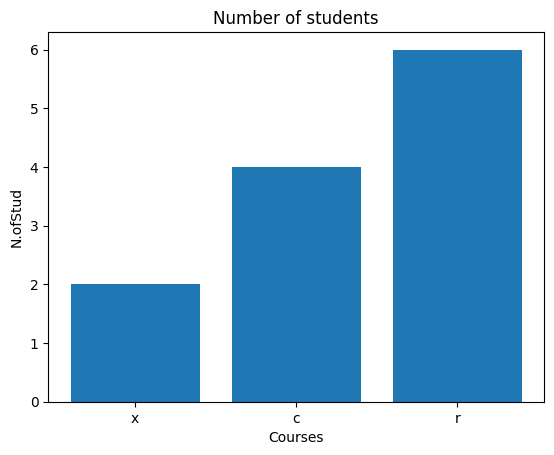

In [1]:
import matplotlib.pyplot as plt

cat = ['x', 'c', 'r']
values = [2, 4, 6]

fig = plt.bar(cat, values)
plt.title('Number of students')
plt.xlabel('Courses')
plt.ylabel('N.ofStud')
plt.show()